# DAAAnalyzer_3.0_ThresholdShiftCalc_2TP.ipynb
Created by: JFranco | Created On: 26 DEC 2024 | Last Env: QISHA | Last Run Date: 3 JAN 2025

This Python notebook analyzes the threshold shift and changes in wave one amplitudes between two time points. 
It generates a .csv file that has the calculated DPOAE and ABR threshold shifts for each animal, and then 
descriptive statistics between groups. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt

In [2]:
# Parameters for plotting
conditions = ["Pink","Blue","NonInj"]
pltOrder = conditions
colors = {pltOrder[0]:'mediumorchid',pltOrder[1]:'slateblue', pltOrder[2]:'black'}
legColors = ["mediumorchid","slateblue",'black']

In [2]:
# Parameters for plotting
conditions = ["HABclw","CtrlInj","UnInj"]
pltOrder = conditions
colors = {pltOrder[0]:'goldenrod' , pltOrder[1]:'slateblue', pltOrder[2]:'mediumorchid'}
legColors = ["goldenrod", "slateblue","mediumorchid"]

In [3]:
# *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
prepID = 'CMI_010'
daaRuns = [1,3]
daaTypes = ['Baseline','2 Wks Post Noise Exposure']
#fnMD = prepID+'.Metadata.AnimalInfo.csv'

# Directories 
#   - Existing ones - 
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/DAA/'
dirPrep = dirMain+prepID+'/'
#dirData = dirPrep+'RawData/'
#dirMD = dirPrep+'Metadata/'
dirSV = dirPrep+'Results/'
dirDFs = dirSV+"1_CompiledMeasurements/"
dirDPOAEs = dirSV+"2_DPOAEPlotsByGroup/"
#dirSjABRPlts = dirSV+"3_ABRPlotsBySubject/"
dirGpABRPlts = dirSV+"4_ABRPlotsByGroup/"
#dirSjWOPlts = dirSV+"5_Wave1PlotsBySubject/"
dirGpWOPlts = dirSV+"6_Wave1PlotsByGroup/"

# Filenames
#    - Existing ones -
#fnMD = prepID+'.Metadata.AnimalInfo.csv'
fnBaseDPs = '.DPOAEf2Thresholds.DAA_'
fnBaseABRs = '.ABRThresholds.DAA_'

#    - Ones that will be made - 
fnDPShifts = prepID+'.DPOAEThresholdShifts.csv'
fnABRShifts = prepID+'.ABRThresholdShifts.csv'

In [4]:
#    *** LOAD THRESHOLD SHEETS **
dfDPThs = pd.DataFrame()
dfABRThs = pd.DataFrame()
for i in range(len(daaRuns)):
    dfDP = pd.read_csv(dirDFs+prepID+fnBaseDPs+str(daaRuns[i])+'.csv')
    dfABR = pd.read_csv(dirDFs+prepID+fnBaseABRs+str(daaRuns[i])+'.csv')
    dfDPThs = pd.concat([dfDPThs, dfDP])
    dfABRThs = pd.concat([dfABRThs, dfABR])
dfDPThs.drop(['Unnamed: 0'], axis=1, inplace=True)
dfABRThs.drop(['Unnamed: 0','index'], axis=1, inplace=True)

In [5]:
# *** CALCULATE DPOAE THRESHOLD SHIFTS ***
# Iterate through all of the animals
dfDPShifts = pd.DataFrame()
for an in dfDPThs['AnimalID'].unique():
    # Iterate through the number of shifts to calculate
    for i in range(len(daaRuns)-1):
        # Iterate through the frequencies  
        freqs = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==daaRuns[i+1])]['f2Freq_kHz']
        for freq in freqs:
            # Get the threshold for this animal/freq combo at the next DAA_Run
            thSt = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==daaRuns[i])&(dfDPThs['f2Freq_kHz']==freq)]['Thresh_dBSPL'].values[0]
            thEnd = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==daaRuns[i+1])& (dfDPThs['f2Freq_kHz']==freq)]['Thresh_dBSPL'].values[0]
            thShift = thEnd - thSt
            if (len(daaRuns)==2):
                # There are only two time points and the final threshold shift is just the thShift
                thShiftFinal = thShift
            elif ((len(daaRuns)>2)&(i == (len(daaRuns)-2))):
                # This is the final calculation 
                thSt = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==1)& (dfDPThs['f2Freq_kHz']==freq)]['Thresh_dBSPL'].values[0]
                thShiftFinal = thEnd-thSt

            # Create a subset of the original df to build on 
            dfSS = dfDPThs[(dfDPThs['AnimalID']==an) & (dfDPThs['DAA_Run']==i+1)&(dfDPThs['f2Freq_kHz']==freq)].copy()
            dfSS['Shift_'+str(i+1)+'to'+str(i+2)] = thShift
            dfSS['Shift_Final'] = thShiftFinal 
            dfDPShifts = pd.concat([dfDPShifts, dfSS])

dfDPShifts.to_csv(dirDFs+fnDPShifts)

In [6]:
# *** CALCULATE ABR THRESHOLD SHIFTS ***
# Iterate through all of the animals
dfABRShifts = pd.DataFrame()
for an in dfABRThs['AnimalID'].unique():
    # Iterate through the number of shifts to calculate
    for i in range(len(daaRuns)-1):
        # Iterate through the frequencies  
        freqs = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i+1])]['Freq_kHz']
        for freq in freqs:
            # Get the threshold for this animal/freq combo at the next DAA_Run
            thSt = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i])&(dfABRThs['Freq_kHz']==freq)]['Th_dB_Blinded'].values[0]
            thEnd = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i+1])& (dfABRThs['Freq_kHz']==freq)]['Th_dB_Blinded'].values[0]
            thShift = thEnd - thSt

            # Get the wave I amplitude at 80 dB
            woSt = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i])&(dfABRThs['Freq_kHz']==freq)]['W1uV_80dB'].values[0]
            woEnd = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==daaRuns[i+1])& (dfABRThs['Freq_kHz']==freq)]['W1uV_80dB'].values[0]
            woChange = woEnd - woSt
            
            if (len(daaRuns)==2):
                # There are only two time points and the final threshold shift is just the thShift
                thShiftFinal = thShift
            elif ((len(daaRuns)>2)&(i == (len(daaRuns)-2))):
                # This is the final calculation 
                thSt = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==1)& (dfABRThs['Freq_kHz']==freq)]['Th_dB_Blinded'].values[0]
                thShiftFinal = thEnd-thSt

            # Create a subset of the original df to build on 
            dfSS = dfABRThs[(dfABRThs['AnimalID']==an) & (dfABRThs['DAA_Run']==i+1)&(dfABRThs['Freq_kHz']==freq)].copy()
            dfSS['Shift_'+str(i+1)+'to'+str(i+2)] = thShift
            dfSS['W1Change_'+str(i+1)+'to'+str(i+2)+'_uV'] = woChange
            dfSS['Shift_Final'] = thShiftFinal 
            dfABRShifts = pd.concat([dfABRShifts, dfSS])

dfABRShifts.to_csv(dirDFs+fnABRShifts)

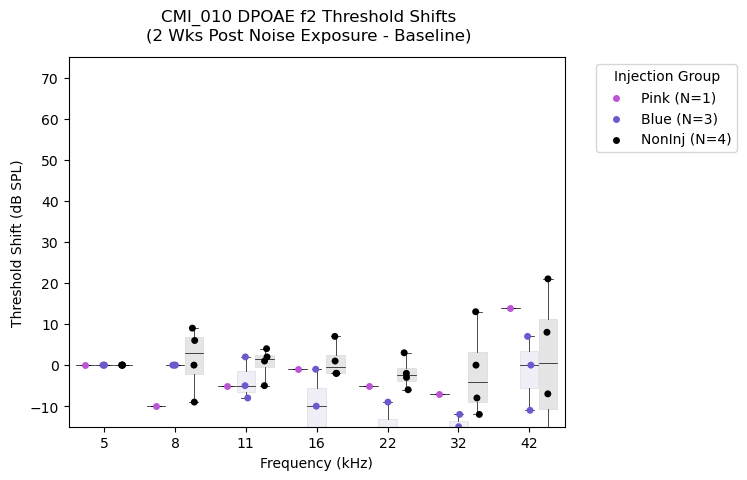

In [7]:
# *** PLOT DPOAE f2 THRESHOLD SHIFTS ***
plot = "DPOAEf2ThresholdShifts.Shift_"+str(daaRuns[0])+"."+str(daaRuns[1])
plottype = "BoxStrip"
title = prepID+" DPOAE f2 Threshold Shifts\n("+daaTypes[1]+' - '+daaTypes[0]+')'
hue = 'InjGroup'
x = 'f2Freq_kHz'
data = dfDPShifts
y='Shift_1to2'
xlab = "Frequency (kHz)"
ylab ="Threshold Shift (dB SPL)"
ymin = -15
ymax = 75
savLoc = dirDPOAEs

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

# Setup the plot
ax1 = sns.stripplot(data=data,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=data,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(data[data['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])
    
plt.legend(title='Injection Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
    
plt.savefig(savLoc+prepID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')

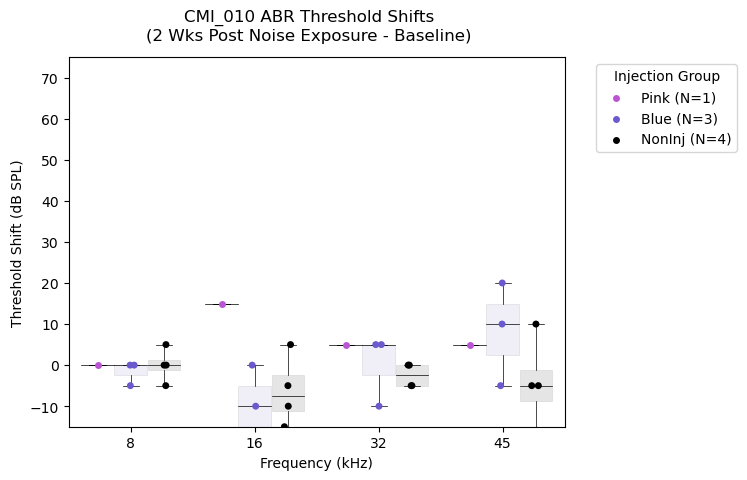

In [8]:
# *** PLOT ABR THRESHOLD SHIFTS ***
plot = "ABRThresholdShifts.Shift_"+str(daaRuns[0])+"."+str(daaRuns[1])
plottype = "BoxStrip"
title = prepID+" ABR Threshold Shifts\n("+daaTypes[1]+' - '+daaTypes[0]+')'
hue = 'InjGroup'
x = 'Freq_kHz'
data = dfABRShifts
y='Shift_1to2'
xlab = "Frequency (kHz)"
ylab ="Threshold Shift (dB SPL)"
ymin = -15
ymax = 75
savLoc = dirGpABRPlts

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

# Setup the plot
ax1 = sns.stripplot(data=data,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=data,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(data[data['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])
    
plt.legend(title='Injection Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
    
plt.savefig(savLoc+prepID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')

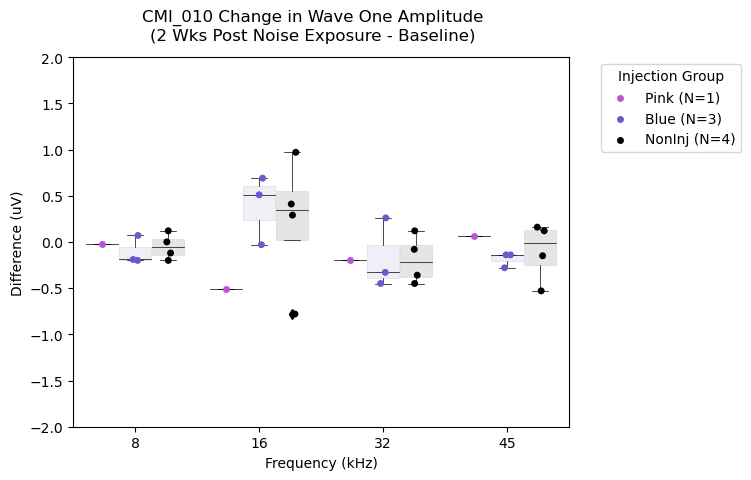

In [9]:
# *** PLOT CHANGE IN WAVE ONE AMPLITUDES ***
plot = "ChangeInWaveOneAmp.Shift_"+str(daaRuns[0])+"."+str(daaRuns[1])
plottype = "BoxStrip"
title = prepID+" Change in Wave One Amplitude\n("+daaTypes[1]+' - '+daaTypes[0]+')'
hue = 'InjGroup'
x = 'Freq_kHz'
data = dfABRShifts
y='W1Change_1to2_uV'
xlab = "Frequency (kHz)"
ylab ='Difference (uV)'
ymin = -2
ymax = 2
savLoc = dirGpWOPlts

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

# Setup the plot
ax1 = sns.stripplot(data=data,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=data,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(data[data['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])
    
plt.legend(title='Injection Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
    
plt.savefig(savLoc+prepID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')